In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../../data/ecommerce.db")

orders = pd.read_sql("SELECT * FROM orders LIMIT 5", conn)
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [9]:
conn = sqlite3.connect("../../data/ecommerce.db")

orders = pd.read_sql("SELECT * FROM orders", conn)
items = pd.read_sql("SELECT * FROM order_items", conn)
payments = pd.read_sql("SELECT * FROM payments", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
products = pd.read_sql("SELECT * FROM products", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)

In [10]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - 
    orders["order_purchase_timestamp"]
).dt.days

In [11]:
df = (orders
      .query("order_status == 'delivered'")
      .merge(payments, on="order_id")
      .merge(customers, on="customer_id")
      .merge(items, on="order_id")
      .merge(products, on="product_id")
      .merge(reviews[["order_id","review_score"]], on="order_id", how="left")
)

print(f"Итоговый датафрейм: {df.shape}")
df.head(3)

Итоговый датафрейм: (115720, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,delivery_days,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.0,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.0,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.0,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0


/var/folders/pl/cc7_bkds01z7dcnyf792_c680000gn/T/ipykernel_894/3882825770.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(revenue_monthly["month"], rotation=45, ha="right")


FileNotFoundError: [Errno 2] No such file or directory: '../images/revenue_monthly.png'

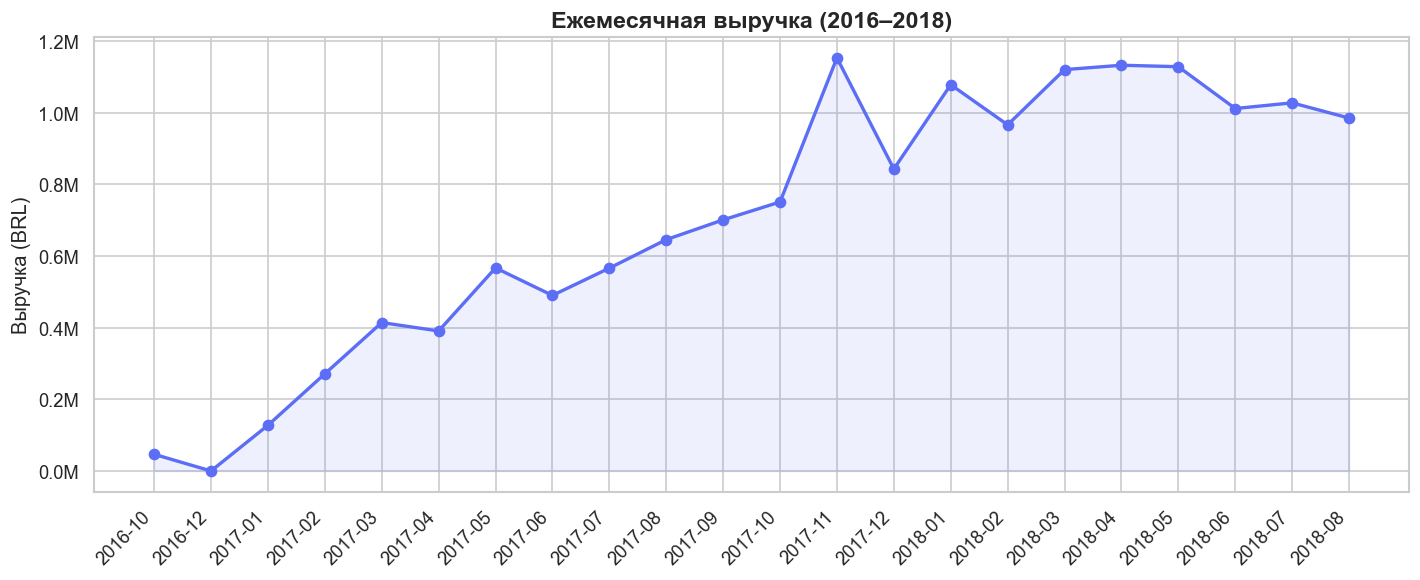

In [ ]:
revenue_monthly = pd.read_sql("""
    SELECT strftime('%Y-%m', order_purchase_timestamp) AS month,
           ROUND(SUM(payment_value), 2) AS revenue
    FROM orders o JOIN payments p ON o.order_id = p.order_id
    WHERE order_status = 'delivered'
    GROUP BY month ORDER BY month
""", conn)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(revenue_monthly["month"], revenue_monthly["revenue"], 
        marker="o", linewidth=2, color="#5B6EF5")
ax.fill_between(range(len(revenue_monthly)), revenue_monthly["revenue"], alpha=0.1, color="#5B6EF5")
ax.set_xticklabels(revenue_monthly["month"], rotation=45, ha="right")
ax.set_title("Ежемесячная выручка (2016–2018)", fontsize=14, fontweight="bold")
ax.set_ylabel("Выручка (BRL)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../../images/revenue_monthly.png", bbox_inches="tight")
plt.show()

In [ ]:
top_cats = pd.read_sql("""
    SELECT product_category_name,
           ROUND(SUM(price), 2) AS total_revenue
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    ORDER BY total_revenue DESC LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cats["product_category_name"][::-1], 
               top_cats["total_revenue"][::-1], color="#5B6EF5")
ax.set_title("Топ-10 категорий товаров по выручке", fontsize=14, fontweight="bold")
ax.set_xlabel("Выручка (BRL)")
for bar in bars:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width()/1e6:.1f}M", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../images/top_categories.png", bbox_inches="tight")
plt.show()

In [ ]:
delivered = orders.query("order_status == 'delivered' and delivery_days > 0 and delivery_days < 60")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delivered["delivery_days"], bins=40, color="#5B6EF5", edgecolor="white", alpha=0.85)
ax.axvline(delivered["delivery_days"].median(), color="red", linestyle="--", 
           label=f'Медиана: {delivered["delivery_days"].median():.0f} дней')
ax.set_title("Распределение времени доставки", fontsize=14, fontweight="bold")
ax.set_xlabel("Дней до доставки")
ax.set_ylabel("Количество заказов")
ax.legend()
plt.tight_layout()
plt.savefig("../images/delivery_distribution.png", bbox_inches="tight")
plt.show()

In [ ]:
scores = reviews["review_score"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#FF4444","#FF9900","#FFD700","#90EE90","#2ECC71"]
bars = ax.bar(scores.index, scores.values, color=colors, edgecolor="white")
ax.set_title("Распределение оценок покупателей", fontsize=14, fontweight="bold")
ax.set_xlabel("Оценка (1–5)")
ax.set_ylabel("Количество отзывов")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{bar.get_height():,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../images/review_scores.png", bbox_inches="tight")
plt.show()

In [ ]:
scatter_df = df.groupby("product_category_name").agg(
    avg_price=("price","mean"),
    avg_score=("review_score","mean"),
    count=("order_id","count")
).query("count > 200").reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(scatter_df["avg_price"], scatter_df["avg_score"],
                s=scatter_df["count"]/5, alpha=0.6, c=scatter_df["avg_price"], 
                cmap="Blues", edgecolors="gray", linewidths=0.5)
for _, row in scatter_df.iterrows():
    ax.annotate(row["product_category_name"], 
                (row["avg_price"], row["avg_score"]), fontsize=7, alpha=0.8)
ax.set_title("Средняя цена vs. Средняя оценка по категориям", fontsize=13, fontweight="bold")
ax.set_xlabel("Средняя цена (BRL)")
ax.set_ylabel("Средняя оценка")
plt.tight_layout()
plt.savefig("../images/price_vs_score.png", bbox_inches="tight")
plt.show()